#### **Urban Heat Vulnerability Index (UHVI) Development for Newcastle upon Tyne**
1. Product Land Surface Temperature (LST) raster
2. Perform zonal statistics and Gi* hotspot analysis
3. Create explanatory variables for UHVI
4. Develope UHVI

**1. Produce a Land Surface Temperature (LST) raster for Newcastle upon Tyne**

- From Landsat 8/9 Collection 2 Level-2 Surface Temperature
- Using Google Earth Engine



In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1-1 Install packages

!pip install geemap earthengine-api -q

In [ ]:
# 1-2 Import libraries

import ee
import geemap

In [ ]:
# 1-3 Authenticate and initialise Earth Engine

ee.Authenticate()
ee.Initialize(project='newcastle-lst-project')

In [ ]:
# 1-4 Select an area covering Newcastle upon Tyne

newcastle = ee.Geometry.Rectangle([
    -1.78, 54.88,   # west, south
    -1.45, 55.08    # east, north
])

Map = geemap.Map(center=[54.9783, -1.6178], zoom=11)
Map.addLayer(newcastle, {}, "Newcastle upon Tyne")
Map

Map(center=[54.9783, -1.6178], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [ ]:
# 1-5 Define Landsat cloud mask function

def mask_landsat_clouds(image):
    qa = image.select("QA_PIXEL")

    # Bits for cloud/shadow masking
    cloud_shadow = 1 << 3
    clouds = 1 << 5

    mask = (
        qa.bitwiseAnd(cloud_shadow).eq(0)
        .And(qa.bitwiseAnd(clouds).eq(0))
    )

    return image.updateMask(mask)

In [ ]:
# 1-6 Convert LST band to Celsius
#    (Landsat Collection 2 Level-2 ST_B10 scale:
#    Kelvin = DN * 0.00341802 + 149.0
#    Celsius = Kelvin - 273.15)

def add_lst_celsius(image):
    lst_c = image.select("ST_B10") \
        .multiply(0.00341802) \
        .add(149.0) \
        .subtract(273.15) \
        .rename("LST_C")

    return image.addBands(lst_c)

In [ ]:
# 1-7 Load Landsat 8 and Landsat 9 imagery (summer period in 2022 for heat vulnerability analysis)

start_date = "2022-06-01"
end_date = "2022-08-31"

landsat8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
landsat9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

landsat = landsat8.merge(landsat9) \
    .filterBounds(newcastle) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt("CLOUD_COVER", 30)) \
    .map(mask_landsat_clouds) \
    .map(add_lst_celsius)

print("Number of images:", landsat.size().getInfo())

Number of images: 7


In [ ]:
# 1-8 Create LST composite raster (using median to reduce cloud/noise effects)

lst_median = landsat.select("LST_C").median().clip(newcastle)

lst_vis = {
    "min": 15,
    "max": 45,
    "palette": [
        "blue", "cyan", "green", "yellow", "orange", "red"
    ]
}

Map = geemap.Map(center=[54.9783, -1.6178], zoom=11)
Map.addLayer(lst_median, lst_vis, "Median Summer LST °C")
Map.addLayer(newcastle, {}, "Study area")
Map

Map(center=[54.9783, -1.6178], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [ ]:
# 1-9 Export LST raster to Google Drive

export_task = ee.batch.Export.image.toDrive(
    image=lst_median,
    description="Newcastle_LST_Median_Summer_2022",
    folder="LST_Project",
    fileNamePrefix="newcastle_lst_median_summer_2022",
    region=newcastle,
    scale=30,
    crs="EPSG:27700",   # British National Grid
    maxPixels=1e13
)

export_task.start()

print("Export started. Check Google Drive > LST_Project.")

Export started. Check Google Drive > LST_Project.


In [ ]:
# 1-10 Check export task status


export_task.status()

{'state': 'READY',
 'description': 'Newcastle_LST_Median_Summer_2022',
 'priority': 100,
 'creation_timestamp_ms': 1781862883148,
 'update_timestamp_ms': 1781862883148,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': 'E5PAY2SO5TYKFZIZRHTMXWJ3',
 'name': 'projects/newcastle-lst-project/operations/E5PAY2SO5TYKFZIZRHTMXWJ3'}

2. Use the LST raster created to perform zonal statistics and Gi* hotspot analysis for Newcastle upon Tyne at the LSOA level

- Downloads LSOA 2021 boundaries for England and Wales, filters Newcastle upon Tyne and save it to Google Drive
- Match LSOA CRS to LST raster CRS
- Perform zonal statistics
- Perform Getis-Ord Gi* hotspot analysis

In [ ]:
# 2-1 Install packages

!pip install geopandas rasterio rasterstats libpysal esda mapclassify pyogrio requests -q

In [ ]:
# 2-2 Import libraries

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

from libpysal.weights import Queen
from esda.getisord import G_Local

import os
import requests

In [ ]:
# 2-3 Set file paths

lst_raster_path = "/content/drive/MyDrive/LST_Project/data/newcastle_lst.tif"
lsoa_path = "/content/drive/MyDrive/LST_Project/data/newcastle_lsoa.shp"

output_folder = "/content/drive/MyDrive/LST_Project/outputs"
output_gpkg = f"{output_folder}/newcastle_lsoa_lst_gistar.gpkg"
output_csv = f"{output_folder}/newcastle_lsoa_lst_gistar.csv"

In [ ]:
# 2-4 Set folders and output paths

data_dir = "/content/drive/MyDrive/LST_Project/data"
os.makedirs(data_dir, exist_ok=True)

all_lsoa_geojson = f"{data_dir}/lsoa_2021_ew_bfc.geojson"
newcastle_output_shp = f"{data_dir}/newcastle_lsoa.shp"
newcastle_output_gpkg = f"{data_dir}/newcastle_lsoa.gpkg"

In [ ]:
# 2-5 Download official ONS LSOA 2021 boundary GeoJSON
#    (Dataset: Lower layer Super Output Areas Dec 2021
#    Boundary type: BFC = full resolution, clipped to coastline)

url = "https://opendata.arcgis.com/api/v3/datasets/2bbaef5230694f3abae4f9145a3a9800_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, stream=True)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("content-type"))

if response.status_code != 200:
    print(response.text[:1000])
    raise Exception("Download failed")

with open(all_lsoa_geojson, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print("Downloaded to:", all_lsoa_geojson)

Status code: 200
Content type: application/json
Downloaded to: /content/drive/MyDrive/LST_Project/data/lsoa_2021_ew_bfc.geojson


In [ ]:
# 2-6 Read the downloaded LSOA GeoJSON file

lsoa = gpd.read_file(all_lsoa_geojson)

print("Rows:", len(lsoa))
print("CRS:", lsoa.crs)
print(lsoa.head())
print(lsoa.columns)

Rows: 35672
CRS: EPSG:4326
   FID   LSOA21CD                   LSOA21NM LSOA21NMW   BNG_E   BNG_N  \
0    1  E01000001        City of London 001A            532123  181632   
1    2  E01000002        City of London 001B            532480  181715   
2    3  E01000003        City of London 001C            532239  182033   
3    4  E01000005        City of London 001E            533581  181283   
4    5  E01000006  Barking and Dagenham 016A            544994  184274   

        LAT      LONG    Shape__Area  Shape__Length  \
0  51.51817 -0.097150  129865.314476    2635.767993   
1  51.51883 -0.091970  228419.782242    2707.816821   
2  51.52174 -0.095330   59054.204697    1224.573160   
3  51.51469 -0.076280  189577.709503    2275.805344   
4  51.53875  0.089317  146536.995750    1966.092607   

                               GlobalID  \
0  c625aea8-6d73-4b2a-be76-4d5c44cad9f8   
1  52c878e9-ac68-4886-b4a8-fea9cd241a70   
2  b9d8faca-d489-478d-8ce6-acaf76186d7d   
3  15e1417d-537c-4845-982

In [ ]:
# 2-7 Check columns

print(lsoa.columns.tolist())
print(lsoa.head())

['FID', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry']
   FID   LSOA21CD                   LSOA21NM LSOA21NMW   BNG_E   BNG_N  \
0    1  E01000001        City of London 001A            532123  181632   
1    2  E01000002        City of London 001B            532480  181715   
2    3  E01000003        City of London 001C            532239  182033   
3    4  E01000005        City of London 001E            533581  181283   
4    5  E01000006  Barking and Dagenham 016A            544994  184274   

        LAT      LONG    Shape__Area  Shape__Length  \
0  51.51817 -0.097150  129865.314476    2635.767993   
1  51.51883 -0.091970  228419.782242    2707.816821   
2  51.52174 -0.095330   59054.204697    1224.573160   
3  51.51469 -0.076280  189577.709503    2275.805344   
4  51.53875  0.089317  146536.995750    1966.092607   

                               GlobalID  \
0  c625aea8-6d73-4b2a-be76-4d5c44cad9f8   
1  5

In [ ]:
# 2-8 Filter Newcastle LSOAs using LSOA name

name_cols = [
    col for col in lsoa.columns
    if "NM" in col.upper() or "NAME" in col.upper()
]

print("Possible name columns:", name_cols)

for col in name_cols:
    print(col)
    print(lsoa[col].dropna().astype(str).head(10).tolist())

Possible name columns: ['LSOA21NM', 'LSOA21NMW']
LSOA21NM
['City of London 001A', 'City of London 001B', 'City of London 001C', 'City of London 001E', 'Barking and Dagenham 016A', 'Barking and Dagenham 015A', 'Barking and Dagenham 015B', 'Barking and Dagenham 016B', 'Barking and Dagenham 016C', 'Barking and Dagenham 015D']
LSOA21NMW
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']


In [ ]:
# 2-9 Find the LSOA name column automatically

target_col = None

for col in name_cols:
    values = lsoa[col].astype(str)
    if values.str.contains("Newcastle upon Tyne", case=False, na=False).any():
        target_col = col
        break

print("Target column:", target_col)

if target_col is None:
    raise Exception("Could not find Newcastle upon Tyne in any name column.")

Target column: LSOA21NM


In [ ]:
# 2-10 Create Newcastle LSOA subset

newcastle_lsoa = lsoa[
    lsoa[target_col].astype(str).str.contains(
        "Newcastle upon Tyne",
        case=False,
        na=False
    )
].copy()

print("Number of Newcastle LSOAs:", len(newcastle_lsoa))
print(newcastle_lsoa[[target_col]].head())

Number of Newcastle LSOAs: 180
                      LSOA21NM
7887  Newcastle upon Tyne 027A
7888  Newcastle upon Tyne 027B
7889  Newcastle upon Tyne 027C
7890  Newcastle upon Tyne 027D
7891  Newcastle upon Tyne 027E


In [ ]:
# 2-11 Reproject and save the Newcastle LSOA subset

newcastle_lsoa = newcastle_lsoa.to_crs("EPSG:27700")

output_shp = "/content/drive/MyDrive/LST_Project/data/newcastle_lsoa.shp"
output_gpkg = "/content/drive/MyDrive/LST_Project/data/newcastle_lsoa.gpkg"

newcastle_lsoa.to_file(output_shp, driver="ESRI Shapefile")
newcastle_lsoa.to_file(output_gpkg, layer="newcastle_lsoa", driver="GPKG")

print("Saved:", output_shp)
print("Saved:", output_gpkg)

Saved: /content/drive/MyDrive/LST_Project/data/newcastle_lsoa.shp
Saved: /content/drive/MyDrive/LST_Project/data/newcastle_lsoa.gpkg


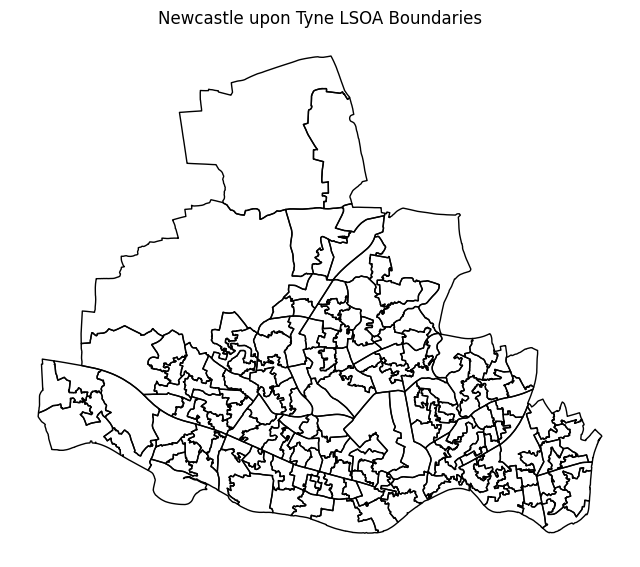

In [ ]:
# 2-12 Check Newcastle LSOAs

ax = newcastle_lsoa.plot(
    figsize=(8, 8),
    edgecolor="black",
    facecolor="none"
)

ax.set_title("Newcastle upon Tyne LSOA Boundaries")
ax.axis("off")

plt.savefig(
    "/content/drive/MyDrive/LST_Project/outputs/newcastle_lsoa_boundaries.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
# 2-13 Read LSOA boundaries

lsoa = gpd.read_file(lsoa_path)

print(lsoa.head())
print(lsoa.crs)

    FID   LSOA21CD                  LSOA21NM LSOA21NMW   BNG_E   BNG_N  \
0  7888  E01008288  Newcastle upon Tyne 027A      None  420626  564662   
1  7889  E01008289  Newcastle upon Tyne 027B      None  421257  564713   
2  7890  E01008290  Newcastle upon Tyne 027C      None  421354  563785   
3  7891  E01008291  Newcastle upon Tyne 027D      None  422274  563691   
4  7892  E01008292  Newcastle upon Tyne 027E      None  420439  565029   

        LAT     LONG     Shape__Are   Shape__Len  \
0  54.97615 -1.67931  377840.169327  5532.129743   
1  54.97658 -1.66944  369431.033142  3623.362712   
2  54.96824 -1.66800  549142.159653  3977.304384   
3  54.96736 -1.65363  524743.229004  4235.118858   
4  54.97946 -1.68220  210034.917480  2640.187858   

                               GlobalID  \
0  e99ca069-ed5e-4559-bea7-f16ca64567df   
1  dc936b70-6ee6-4ba0-b07c-18272ca1fd3e   
2  f2ef01d6-2752-48ce-829d-fb44ef6f3b4b   
3  ea8684af-15b8-46e0-946a-dfd2c884f850   
4  34249a49-650e-4ee1-9e04-

In [ ]:
# 2-14 Match LSOA CRS to LST raster CRS

lst_raster_path = "/content/drive/MyDrive/LST_Project/newcastle_lst_median_summer_2022.tif"

with rasterio.open(lst_raster_path) as src:
    raster_crs = src.crs
    nodata = src.nodata

print("Raster CRS:", raster_crs)
print("Raster nodata:", nodata)

lsoa = lsoa.to_crs(raster_crs)

Raster CRS: EPSG:27700
Raster nodata: None


In [ ]:
# 2-15 Calculate zonal statistics by LSOA

def percentile_95(values):
    values = np.array(values)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan
    return np.percentile(values, 95)

stats = zonal_stats(
    vectors=lsoa,
    raster=lst_raster_path,
    stats=["mean", "median", "max", "count"],
    add_stats={"p95": percentile_95},
    nodata=nodata,
    all_touched=True
)

stats_df = pd.DataFrame(stats)
stats_df.head()

,max,mean,count,median,p95
0,35.803082,32.248263,526,32.472221,34.299666
1,35.273289,32.084761,486,32.427787,34.724184
2,36.264515,32.908572,689,33.037904,35.730962
3,37.935926,33.803137,666,34.314534,36.888816
4,33.988113,30.899266,290,30.240254,33.463789


In [ ]:
# 2-16 Join LST statistics back to LSOAs

lsoa_lst = lsoa.join(stats_df)

lsoa_lst = lsoa_lst.rename(columns={
    "mean": "lst_mean",
    "median": "lst_median",
    "max": "lst_max",
    "p95": "lst_p95",
    "count": "lst_px_count"
})

lsoa_lst[["lst_mean", "lst_median", "lst_max", "lst_p95", "lst_px_count"]].describe()

,lst_mean,lst_median,lst_max,lst_p95,lst_px_count
count,180.000000,180.000000,180.000000,180.000000,180.000000
mean,32.071848,32.248389,36.067504,35.159114,785.544444
std,2.057897,2.133051,1.758759,1.606881,1757.787583
min,26.127000,26.041217,30.525659,29.479574,98.000000
25%,30.740207,30.729245,35.266880,34.416306,332.000000
50%,32.233006,32.479057,36.379018,35.481703,448.000000
75%,33.578877,33.750988,37.119874,36.318178,664.500000
max,36.552954,36.491813,39.542396,37.846032,17831.000000


In [ ]:
# 2-17 Remove LSOAs with missing data

lsoa_lst = lsoa_lst.dropna(subset=["lst_mean"]).copy()
lsoa_lst = lsoa_lst[lsoa_lst["lst_px_count"] > 5].copy()

print("Valid LSOAs:", len(lsoa_lst))

Valid LSOAs: 180


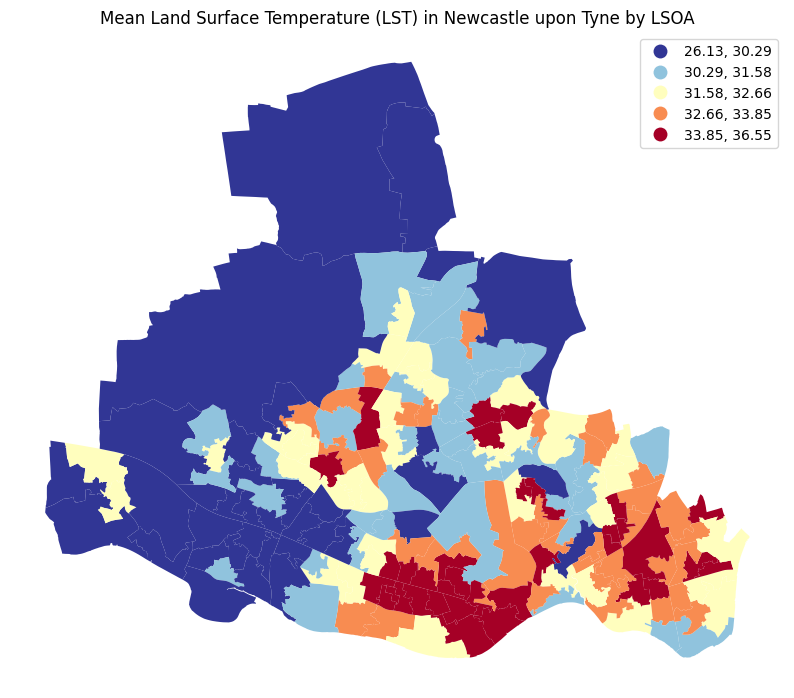

In [ ]:
# 2-18 Map mean LST by LSOA

fig, ax = plt.subplots(figsize=(10, 10))

lsoa_lst.plot(
    column="lst_mean",
    cmap="RdYlBu_r",
    legend=True,
    scheme="quantiles",
    k=5,
    ax=ax
)

ax.set_title("Mean Land Surface Temperature (LST) in Newcastle upon Tyne by LSOA")
ax.axis("off")

plt.savefig(
    "/content/drive/MyDrive/LST_Project/outputs/mean_lst_newcastle_lsoa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 2-19 Build spatial weights for Getis-Ord Gi*

w = Queen.from_dataframe(lsoa_lst)
w.transform = "R"

print("Number of LSOAs in weights:", w.n)

Number of LSOAs in weights: 180


In [ ]:
# 2-20 Run Getis-Ord Gi* hotspot analysis

y = lsoa_lst["lst_mean"].values

gi_star = G_Local(
    y,
    w,
    star=True,
    permutations=999
)

lsoa_lst["gi_z"] = gi_star.Zs
lsoa_lst["gi_p"] = gi_star.p_sim

In [ ]:
# 2-21 Classify hotspots and coldspots

def classify_gistar(row):
    z = row["gi_z"]
    p = row["gi_p"]

    if p <= 0.01 and z > 0:
        return "Hotspot 99%"
    elif p <= 0.05 and z > 0:
        return "Hotspot 95%"
    elif p <= 0.10 and z > 0:
        return "Hotspot 90%"
    elif p <= 0.01 and z < 0:
        return "Coldspot 99%"
    elif p <= 0.05 and z < 0:
        return "Coldspot 95%"
    elif p <= 0.10 and z < 0:
        return "Coldspot 90%"
    else:
        return "Not significant"

lsoa_lst["hotspot_class"] = lsoa_lst.apply(classify_gistar, axis=1)

lsoa_lst["hotspot_class"].value_counts()

,count
hotspot_class,
Not significant,90
Coldspot 99%,23
Hotspot 99%,20
Coldspot 95%,16
Hotspot 95%,14
Hotspot 90%,13
Coldspot 90%,4


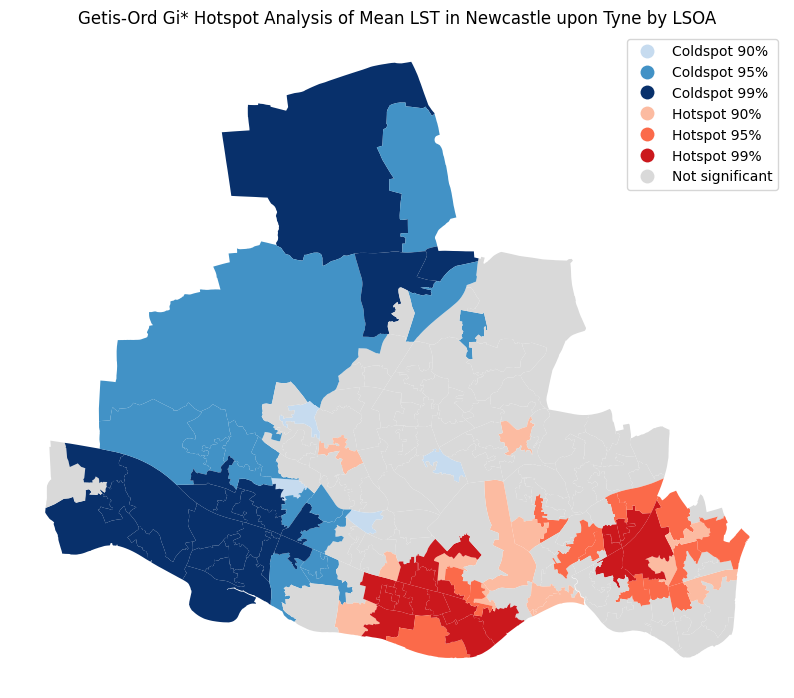

In [ ]:
# 2-22 Map Getis-Ord Gi* hotspots

from matplotlib.colors import ListedColormap

# Define colors:
# Dark blue -> light blue -> grey -> light red -> dark red
hotspot_colors = [
    "#c6dbef",  # -1 Weak cold spot (90%)
    "#4292c6",  # -2 Cold spot (95%)
    "#08306b",  # -3 Strong cold spot (99%)
    "#fcbba1",  #  1 Weak hot spot (90%)
    "#fb6a4a",  #  2 Hot spot (95%)
    "#cb181d",   #  3 Strong hot spot (99%)
    "#d9d9d9",  #  0 Not significant
]

cmap = ListedColormap(hotspot_colors)

fig, ax = plt.subplots(figsize=(10, 10))

lsoa_lst.plot(
    column="hotspot_class",
    categorical=True,
    cmap=cmap,
    legend=True,
    ax=ax
)

ax.set_title(
    "Getis-Ord Gi* Hotspot Analysis of Mean LST in Newcastle upon Tyne by LSOA"
)
ax.axis("off")

plt.savefig(
    "/content/drive/MyDrive/LST_Project/outputs/hotspot_analysis_mean_lst_newcastle_lsoa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 2-23 Save outputs to Google Drive

lsoa_lst.to_file(output_gpkg, layer="lsoa_lst_gistar", driver="GPKG")

# Save attribute table without geometry
lsoa_lst.drop(columns="geometry").to_csv(output_csv, index=False)

print("GeoPackage saved to:", output_gpkg)
print("CSV saved to:", output_csv)

GeoPackage saved to: /content/drive/MyDrive/LST_Project/data/newcastle_lsoa.gpkg
CSV saved to: /content/drive/MyDrive/LST_Project/outputs/newcastle_lsoa_lst_gistar.csv


**3. Create explanatory variables for Urban Heat Vulnerability Index development**

**Explanatory variables:**

*3A - Environmental Variables from Sentinel-2*
* NDVI
* NDBI
* Impervious surfaces

*3B - Urban morphology variables from OS Open Data:*
* Building density
* Road density

*3C - Social vulnerability variables from Census:*
* Population density
* Age 65+
* Age 75+
* Disability

*3D - Socio-economic variables from IMD:*
* Overall deprivation
* Health deprivation

*3E - Create binary hotspot variable*

In [ ]:
# Install required packages

!pip install scikit-learn -q

In [ ]:
# Import libraries

from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Set project paths and load LSOA geometry and LST CSV

base_dir = "/content/drive/MyDrive/LST_Project"
data_dir = f"{base_dir}/data"
output_dir = f"{base_dir}/outputs"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

# Input files
lsoa_gpkg = f"{data_dir}/newcastle_lsoa.gpkg"
lst_csv = f"{output_dir}/newcastle_lsoa_lst_gistar.csv"

# Load Newcastle LSOA boundaries
lsoa_geom = gpd.read_file(lsoa_gpkg)

# Load LST + hotspot statistics
lst_stats = pd.read_csv(lst_csv)

print("Geometry columns:")
print(lsoa_geom.columns.tolist())

print("\nCSV columns:")
print(lst_stats.columns.tolist())

print("\nGeometry CRS:")
print(lsoa_geom.crs)

print("\nGeometry rows:", len(lsoa_geom))
print("CSV rows:", len(lst_stats))

Geometry columns:
['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry']

CSV columns:
['FID', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Are', 'Shape__Len', 'GlobalID', 'lst_max', 'lst_mean', 'lst_px_count', 'lst_median', 'lst_p95', 'gi_z', 'gi_p', 'hotspot_class']

Geometry CRS:
EPSG:27700

Geometry rows: 180
CSV rows: 180


In [ ]:
# Standardise join column

# Find likely LSOA code column in geometry
print([c for c in lsoa_geom.columns if "LSOA" in c.upper()])

# Find likely LSOA code column in CSV
print([c for c in lst_stats.columns if "LSOA" in c.upper()])

['LSOA21CD', 'LSOA21NM', 'LSOA21NMW']
['LSOA21CD', 'LSOA21NM', 'LSOA21NMW']


In [ ]:
# Merge geometry with LST statistics

lsoa = lsoa_geom.merge(
    lst_stats,
    on="LSOA21CD",
    how="left"
)

print("Merged rows:", len(lsoa))
print("Missing lst_mean:", lsoa["lst_mean"].isna().sum())
print("CRS:", lsoa.crs)

print(lsoa.columns.tolist())
display(lsoa.head())

Merged rows: 180
Missing lst_mean: 0
CRS: EPSG:27700
['LSOA21CD', 'LSOA21NM_x', 'LSOA21NMW_x', 'BNG_E_x', 'BNG_N_x', 'LAT_x', 'LONG_x', 'Shape__Area', 'Shape__Length', 'GlobalID_x', 'geometry', 'FID', 'LSOA21NM_y', 'LSOA21NMW_y', 'BNG_E_y', 'BNG_N_y', 'LAT_y', 'LONG_y', 'Shape__Are', 'Shape__Len', 'GlobalID_y', 'lst_max', 'lst_mean', 'lst_px_count', 'lst_median', 'lst_p95', 'gi_z', 'gi_p', 'hotspot_class']


,LSOA21CD,LSOA21NM_x,LSOA21NMW_x,BNG_E_x,BNG_N_x,LAT_x,LONG_x,Shape__Area,Shape__Length,GlobalID_x,...,Shape__Len,GlobalID_y,lst_max,lst_mean,lst_px_count,lst_median,lst_p95,gi_z,gi_p,hotspot_class
0,E01008288,Newcastle upon Tyne 027A,,420626,564662,54.97615,-1.67931,377840.169327,5532.129743,e99ca069-ed5e-4559-bea7-f16ca64567df,...,5532.129743,e99ca069-ed5e-4559-bea7-f16ca64567df,35.803082,32.248263,526,32.472221,34.299666,-0.611512,0.035,Coldspot 95%
1,E01008289,Newcastle upon Tyne 027B,,421257,564713,54.97658,-1.66944,369431.033142,3623.362712,dc936b70-6ee6-4ba0-b07c-18272ca1fd3e,...,3623.362712,dc936b70-6ee6-4ba0-b07c-18272ca1fd3e,35.273289,32.084761,486,32.427787,34.724184,0.018461,0.466,Not significant
2,E01008290,Newcastle upon Tyne 027C,,421354,563785,54.96824,-1.66800,549142.159653,3977.304384,f2ef01d6-2752-48ce-829d-fb44ef6f3b4b,...,3977.304384,f2ef01d6-2752-48ce-829d-fb44ef6f3b4b,36.264515,32.908572,689,33.037904,35.730962,0.575830,0.060,Hotspot 90%
3,E01008291,Newcastle upon Tyne 027D,,422274,563691,54.96736,-1.65363,524743.229004,4235.118858,ea8684af-15b8-46e0-946a-dfd2c884f850,...,4235.118858,ea8684af-15b8-46e0-946a-dfd2c884f850,37.935926,33.803137,666,34.314534,36.888816,1.061395,0.001,Hotspot 99%
4,E01008292,Newcastle upon Tyne 027E,,420439,565029,54.97946,-1.68220,210034.917480,2640.187858,34249a49-650e-4ee1-9e04-30e8439b6021,...,2640.187858,34249a49-650e-4ee1-9e04-30e8439b6021,33.988113,30.899266,290,30.240254,33.463789,-1.026931,0.011,Coldspot 95%


In [ ]:
# Save merged GeoPackage

merged_gpkg = f"{output_dir}/newcastle_lsoa_lst_gistar.gpkg"

lsoa.to_file(
    merged_gpkg,
    layer="lsoa_lst_gistar",
    driver="GPKG"
)

print("Saved merged GeoPackage:")
print(merged_gpkg)

Saved merged GeoPackage:
/content/drive/MyDrive/LST_Project/outputs/newcastle_lsoa_lst_gistar.gpkg


In [ ]:
# Set project paths

base_dir = "/content/drive/MyDrive/LST_Project"
data_dir = f"{base_dir}/data"
output_dir = f"{base_dir}/outputs"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

lst_gpkg = f"{output_dir}/newcastle_lsoa_lst_gistar.gpkg"

lsoa = gpd.read_file(lst_gpkg)

print(lsoa.columns)
print(lsoa.crs)
print(len(lsoa))

Index(['LSOA21CD', 'LSOA21NM_x', 'LSOA21NMW_x', 'BNG_E_x', 'BNG_N_x', 'LAT_x',
       'LONG_x', 'Shape__Area', 'Shape__Length', 'GlobalID_x', 'LSOA21NM_y',
       'LSOA21NMW_y', 'BNG_E_y', 'BNG_N_y', 'LAT_y', 'LONG_y', 'Shape__Are',
       'Shape__Len', 'GlobalID_y', 'lst_max', 'lst_mean', 'lst_px_count',
       'lst_median', 'lst_p95', 'gi_z', 'gi_p', 'hotspot_class', 'geometry'],
      dtype='object')
EPSG:27700
180


3A. Sentinel-2 variables: NDVI, NDBI, impervious surface proxy
(using Google Earth Engine)

In [ ]:
# 3A-1 Authenticate Earth Engine

import ee
import geemap

ee.Authenticate()

ee.Initialize(project="sentinel-2-variables")

In [ ]:
# 3A-2 Select an area covering Newcastle upon Tyne from LSOA boundary

lsoa_wgs84 = lsoa.to_crs("EPSG:4326")

minx, miny, maxx, maxy = lsoa_wgs84.total_bounds

newcastle_geom = ee.Geometry.Rectangle([
    float(minx), float(miny), float(maxx), float(maxy)
])

In [ ]:
# 3A-3 Build cloud-masked Sentinel-2 summer composite

def mask_s2_clouds(image):
    scl = image.select("SCL")

    mask = (
        scl.neq(3)    # cloud shadow
        .And(scl.neq(8))    # cloud medium probability
        .And(scl.neq(9))    # cloud high probability
        .And(scl.neq(10))   # cirrus
        .And(scl.neq(11))   # snow
    )

    return image.updateMask(mask)


s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(newcastle_geom)
    .filterDate("2022-06-01", "2022-08-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(mask_s2_clouds)
    .median()
    .clip(newcastle_geom)
)

# NDVI = vegetation
ndvi = (
    s2.normalizedDifference(["B8", "B4"])
    .rename("NDVI")
    .toFloat()
)

# NDBI = built-up / impervious tendency
ndbi = (
    s2.normalizedDifference(["B11", "B8"])
    .rename("NDBI")
    .toFloat()
)

# Binary proxy layers, converted to Float32
impervious_proxy = (
    ndbi.gt(0.1)
    .rename("impervious_proxy")
    .toFloat()
)

green_proxy = (
    ndvi.gt(0.4)
    .rename("green_proxy")
    .toFloat()
)

tree_proxy = (
    ndvi.gt(0.6)
    .rename("tree_canopy_proxy")
    .toFloat()
)

# Stack all bands and force same data type
eo_stack = (
    ndvi
    .addBands(ndbi)
    .addBands(impervious_proxy)
    .addBands(green_proxy)
    .addBands(tree_proxy)
    .toFloat()
)

In [ ]:
# 3A-4 Export Sentinel-2 variables to Google Drive

task = ee.batch.Export.image.toDrive(
    image=eo_stack,
    description="newcastle_sentinel2_indices_2022",
    folder="LST_Project",
    fileNamePrefix="newcastle_sentinel2_indices_2022",
    region=newcastle_geom,
    scale=10,
    crs="EPSG:27700",
    maxPixels=1e13
)

task.start()

print("Export started. Wait until it completes before running the next step.")

Export started. Wait until it completes before running the next step.


In [ ]:
# 3A-5 Check Earth Engine export status

task.status()

{'state': 'RUNNING',
 'description': 'newcastle_sentinel2_indices_2022',
 'priority': 100,
 'creation_timestamp_ms': 1781863828073,
 'update_timestamp_ms': 1781863838128,
 'start_timestamp_ms': 1781863833219,
 'task_type': 'EXPORT_IMAGE',
 'attempt': 1,
 'id': 'VBCSDX66354R7STBUBH5LYKZ',
 'name': 'projects/sentinel-2-variables/operations/VBCSDX66354R7STBUBH5LYKZ'}

In [ ]:
# 3A-6 After export finishes, move the raster the following folder:

s2_indices_path = f"{base_dir}/newcastle_sentinel2_indices_2022.tif"

In [ ]:
# 3A-7 Aggregate Sentinel-2 variables to LSOA level

with rasterio.open(s2_indices_path) as src:
    raster_crs = src.crs
    band_count = src.count

lsoa = lsoa.to_crs(raster_crs)

band_names = [
    "ndvi_mean",
    "ndbi_mean",
    "impervious_pct",
    "green_pct",
    "tree_canopy_pct"
]

for band_idx, var_name in enumerate(band_names, start=1):
    stats = zonal_stats(
        lsoa,
        s2_indices_path,
        band=band_idx,
        stats=["mean"],
        all_touched=True,
        nodata=None
    )

    lsoa[var_name] = [s["mean"] for s in stats]

# Convert binary proxy means to percentages
lsoa["impervious_pct"] = lsoa["impervious_pct"] * 100
lsoa["green_pct"] = lsoa["green_pct"] * 100
lsoa["tree_canopy_pct"] = lsoa["tree_canopy_pct"] * 100

lsoa[band_names].describe()

,ndvi_mean,ndbi_mean,impervious_pct,green_pct,tree_canopy_pct
count,180.000000,180.000000,180.000000,180.000000,180.000000
mean,0.425407,-0.034966,18.423377,50.693370,25.791944
std,0.097137,0.053396,9.162026,16.883562,13.340575
min,0.140023,-0.194668,4.626514,2.714932,0.361991
25%,0.378427,-0.065667,12.705824,42.368194,15.205179
50%,0.432603,-0.031457,17.000257,52.329821,24.635404
75%,0.484354,-0.000947,22.474736,60.541534,34.177654
max,0.648243,0.104754,53.101105,85.964546,60.415966


*3B - Urban morphology variables:*

Urban morphology is represented using road density derived from OSMnx and built-up surface proxies derived from Sentinel-2 NDBI and impervious surface classification, as they are lighter and more reproducible

* Road density: using roads only from OSMnx (using all OSM buildings for the whole city of Newcastle can be too heavy)
* Building/built-up density: using the existing Sentinel-2 variables ndbi_mean and impervious_pct instead of building footfrint density (building footprint density was not used due to limitations in open-access building footprint coverage and download reliability)




In [ ]:
# 3B-1 Install packages

!pip install osmnx -q

In [ ]:
# 3B-2 Import library

import osmnx as ox

In [ ]:
# 3B-3 Prepare study area

lsoa = lsoa.to_crs("EPSG:27700")

study_area = lsoa.dissolve()
study_area_wgs84 = study_area.to_crs("EPSG:4326")

study_polygon = study_area_wgs84.geometry.iloc[0]

print("Study area ready")

Study area ready


In [ ]:
# 3B-4 Set overpass endpoint and timeout

ox.settings.timeout = 600
ox.settings.overpass_endpoint = "https://overpass.kumi.systems/api/interpreter"
ox.settings.use_cache = True
ox.settings.log_console = True

In [ ]:
# 3B-5 Download drivable road network

roads_graph = ox.graph_from_polygon(
    study_polygon,
    network_type="drive",
    simplify=True
)

nodes, roads = ox.graph_to_gdfs(
    roads_graph,
    nodes=True,
    edges=True
)

roads = roads.reset_index()
roads = roads.to_crs("EPSG:27700")

print("Road segments downloaded:", len(roads))

Road segments downloaded: 23591


In [ ]:
# 3B-6 Clip roads to Newcastle boundary

roads = gpd.clip(roads, study_area)

print("Clipped roads:", len(roads))

Clipped roads: 23591


In [ ]:
# 3B-7 Save roads

data_dir = "/content/drive/MyDrive/LST_Project/data"
os.makedirs(data_dir, exist_ok=True)

roads_out = f"{data_dir}/newcastle_osm_roads.gpkg"

roads.to_file(
    roads_out,
    layer="roads",
    driver="GPKG"
)

print("Saved roads:", roads_out)

Saved roads: /content/drive/MyDrive/LST_Project/data/newcastle_osm_roads.gpkg


In [ ]:
# 3B-8 Road density calculation by LSOA

lsoa["lsoa_area_m2"] = lsoa.geometry.area

roads["road_length_m"] = roads.geometry.length

road_join = gpd.sjoin(
    roads,
    lsoa[["LSOA21CD", "geometry"]],
    how="inner",
    predicate="intersects"
)

road_stats = (
    road_join
    .groupby("LSOA21CD")["road_length_m"]
    .sum()
    .reset_index()
)

lsoa = lsoa.merge(
    road_stats,
    on="LSOA21CD",
    how="left"
)

lsoa["road_length_m"] = lsoa["road_length_m"].fillna(0)

lsoa["road_density_km_per_km2"] = (
    (lsoa["road_length_m"] / 1000) /
    (lsoa["lsoa_area_m2"] / 1_000_000)
)

lsoa[["LSOA21CD", "road_density_km_per_km2"]].head()

,LSOA21CD,road_density_km_per_km2
0,E01008288,37.425484
1,E01008289,38.603392
2,E01008290,38.112130
3,E01008291,41.205092
4,E01008292,48.573442


In [ ]:
# 3B-9 Building/built-up density - using the existing Sentinel-2 variables: ndbi_mean and impervious_pct

lsoa["built_up_index"] = lsoa["ndbi_mean"]
lsoa["built_up_density_proxy"] = lsoa["impervious_pct"]

lsoa[
    [
        "LSOA21CD",
        "ndbi_mean",
        "impervious_pct",
        "built_up_index",
        "built_up_density_proxy"
    ]
].head()

,LSOA21CD,ndbi_mean,impervious_pct,built_up_index,built_up_density_proxy
0,E01008288,-0.029532,16.990763,-0.029532,16.990763
1,E01008289,-0.065000,9.567664,-0.065000,9.567664
2,E01008290,-0.059441,15.073273,-0.059441,15.073273
3,E01008291,-0.039057,15.609667,-0.039057,15.609667
4,E01008292,-0.004831,18.722467,-0.004831,18.722467


3C. Census variables:

- population_density
- age_65_pct
- age_75_pct
- disability_pct

In [ ]:
# 3C-1 Import library

import zipfile

In [ ]:
# 3C-2 Set project paths

base_dir = "/content/drive/MyDrive/LST_Project"
data_dir = f"{base_dir}/data"
output_dir = f"{base_dir}/outputs"
census_dir = f"{data_dir}/census"

os.makedirs(census_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# 3C-3 Download and extract Nomis Census 2021 bulk ZIPs

def download_and_extract_nomis(table_code, census_dir):
    """
    Downloads a Nomis Census 2021 bulk table ZIP and extracts it.
    Example table_code: "ts001", "ts006", "ts007a", "ts038"
    """
    table_code = table_code.lower()
    url = f"https://www.nomisweb.co.uk/output/census/2021/census2021-{table_code}.zip"
    zip_path = f"{census_dir}/census2021-{table_code}.zip"
    extract_dir = f"{census_dir}/census2021-{table_code}"

    os.makedirs(extract_dir, exist_ok=True)

    if not os.path.exists(zip_path):
        print(f"Downloading {table_code}...")
        r = requests.get(url)
        print("Status:", r.status_code)

        if r.status_code != 200:
            print(r.text[:500])
            raise Exception(f"Failed to download {table_code}")

        with open(zip_path, "wb") as f:
            f.write(r.content)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    print(f"Extracted {table_code} to:", extract_dir)
    return extract_dir


ts001_dir = download_and_extract_nomis("ts001", census_dir)    # population
ts006_dir = download_and_extract_nomis("ts006", census_dir)    # population density
ts007a_dir = download_and_extract_nomis("ts007a", census_dir)  # age five-year bands
ts038_dir = download_and_extract_nomis("ts038", census_dir)    # disability

Extracted ts001 to: /content/drive/MyDrive/LST_Project/data/census/census2021-ts001
Extracted ts006 to: /content/drive/MyDrive/LST_Project/data/census/census2021-ts006
Extracted ts007a to: /content/drive/MyDrive/LST_Project/data/census/census2021-ts007a
Extracted ts038 to: /content/drive/MyDrive/LST_Project/data/census/census2021-ts038


In [ ]:
# 3C-4 Find the LSOA CSV in each extracted folder

def find_lsoa_csv(folder):
    """
    Finds the LSOA-level CSV inside a Nomis Census 2021 bulk download.
    Usually named like census2021-ts007a-lsoa.csv.
    """
    candidates = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            f = file.lower()
            if f.endswith(".csv") and "lsoa" in f:
                candidates.append(os.path.join(root, file))

    if len(candidates) == 0:
        raise Exception(f"No LSOA CSV found in {folder}")

    print("Using:", candidates[0])
    return candidates[0]


ts001_lsoa_csv = find_lsoa_csv(ts001_dir)
ts006_lsoa_csv = find_lsoa_csv(ts006_dir)
ts007a_lsoa_csv = find_lsoa_csv(ts007a_dir)
ts038_lsoa_csv = find_lsoa_csv(ts038_dir)

Using: /content/drive/MyDrive/LST_Project/data/census/census2021-ts001/census2021-ts001-lsoa.csv
Using: /content/drive/MyDrive/LST_Project/data/census/census2021-ts006/census2021-ts006-lsoa.csv
Using: /content/drive/MyDrive/LST_Project/data/census/census2021-ts007a/census2021-ts007a-lsoa.csv
Using: /content/drive/MyDrive/LST_Project/data/census/census2021-ts038/census2021-ts038-lsoa.csv


In [ ]:
# 3C-5 Load Census tables

pop = pd.read_csv(ts001_lsoa_csv)
pop_density = pd.read_csv(ts006_lsoa_csv)
age = pd.read_csv(ts007a_lsoa_csv)
disability = pd.read_csv(ts038_lsoa_csv)

print("Population columns:")
print(pop.columns.tolist())

print("\nPopulation density columns:")
print(pop_density.columns.tolist())

print("\nAge columns:")
print(age.columns.tolist())

print("\nDisability columns:")
print(disability.columns.tolist())

Population columns:
['date', 'geography', 'geography code', 'Residence type: Total; measures: Value', 'Residence type: Lives in a household; measures: Value', 'Residence type: Lives in a communal establishment; measures: Value']

Population density columns:
['date', 'geography', 'geography code', 'Population Density: Persons per square kilometre; measures: Value']

Age columns:
['date', 'geography', 'geography code', 'Age: Total', 'Age: Aged 4 years and under', 'Age: Aged 5 to 9 years', 'Age: Aged 10 to 14 years', 'Age: Aged 15 to 19 years', 'Age: Aged 20 to 24 years', 'Age: Aged 25 to 29 years', 'Age: Aged 30 to 34 years', 'Age: Aged 35 to 39 years', 'Age: Aged 40 to 44 years', 'Age: Aged 45 to 49 years', 'Age: Aged 50 to 54 years', 'Age: Aged 55 to 59 years', 'Age: Aged 60 to 64 years', 'Age: Aged 65 to 69 years', 'Age: Aged 70 to 74 years', 'Age: Aged 75 to 79 years', 'Age: Aged 80 to 84 years', 'Age: Aged 85 years and over']

Disability columns:
['date', 'geography', 'geography cod

In [ ]:
# 3C-6 Standardise geography code column

def standardise_geo_code(df):
    """
    Renames the geography code column to LSOA21CD.
    """
    possible_cols = [
        "geography code",
        "Geography code",
        "GEOGRAPHY_CODE",
        "LSOA21CD",
        "LSOA code"
    ]

    for col in possible_cols:
        if col in df.columns:
            return df.rename(columns={col: "LSOA21CD"})

    raise Exception(f"No geography code column found. Columns are: {df.columns.tolist()}")


pop = standardise_geo_code(pop)
pop_density = standardise_geo_code(pop_density)
age = standardise_geo_code(age)
disability = standardise_geo_code(disability)

In [ ]:
# 3C-7 Find a column by keywords

def find_col(df, must_include, prefer=None):

    cols = df.columns.tolist()

    matches = []
    for col in cols:
        low = col.lower()
        if all(k.lower() in low for k in must_include):
            matches.append(col)

    if prefer:
        preferred = []
        for col in matches:
            low = col.lower()
            if all(k.lower() in low for k in prefer):
                preferred.append(col)
        if preferred:
            return preferred[0]

    if matches:
        return matches[0]

    raise Exception(
        f"No column found for {must_include}. Available columns: {cols}"
    )

In [ ]:
# 3C-8 Create total population

# TS001 total usual residents
pop_total_col = find_col(
    pop,
    must_include=["total"],
    prefer=["usual"]
)

census = pop[["LSOA21CD", pop_total_col]].copy()
census = census.rename(columns={pop_total_col: "population"})

census["population"] = pd.to_numeric(census["population"], errors="coerce")

print(census.head())

    LSOA21CD  population
0  E01011954        2284
1  E01011969        1344
2  E01011970        1070
3  E01011971        1323
4  E01033465        1955


In [ ]:
# 3C-9 Create population density

density_col = find_col(
    pop_density,
    must_include=["persons", "square kilometre"]
)

density = pop_density[["LSOA21CD", density_col]].copy()
density = density.rename(columns={density_col: "population_density"})
density["population_density"] = pd.to_numeric(
    density["population_density"],
    errors="coerce"
)

census = census.merge(
    density,
    on="LSOA21CD",
    how="left"
)

census[["population", "population_density"]].describe()

,population,population_density
count,35672.000000,35672.000000
mean,1670.710950,4403.437719
std,354.184111,4606.439322
min,996.000000,2.300000
25%,1440.000000,1206.100000
50%,1605.000000,3494.750000
75%,1833.000000,5830.500000
max,9899.000000,115567.000000


In [ ]:
# 3C-10 Create age 65+ and age 75+ percentages

age_cols = age.columns.tolist()

age_65_cols = [
    col for col in age_cols
    if any(label in col for label in [
        "Age: Aged 65 to 69 years",
        "Age: Aged 70 to 74 years",
        "Age: Aged 75 to 79 years",
        "Age: Aged 80 to 84 years",
        "Age: Aged 85 years and over"
    ])
]

age_75_cols = [
    col for col in age_cols
    if any(label in col for label in [
        "Age: Aged 75 to 79 years",
        "Age: Aged 80 to 84 years",
        "Age: Aged 85 years and over"
    ])
]

print("Age 65+ columns:")
print(age_65_cols)

print("\nAge 75+ columns:")
print(age_75_cols)

if len(age_65_cols) == 0 or len(age_75_cols) == 0:
    raise Exception("Age columns not found. Check printed age.columns above.")

# Remove duplicate columns
selected_cols = ["LSOA21CD"] + list(dict.fromkeys(age_65_cols + age_75_cols))

age_work = age[selected_cols].copy()

for col in list(dict.fromkeys(age_65_cols + age_75_cols)):
    age_work[col] = pd.to_numeric(age_work[col], errors="coerce")

age_work["age_65_plus"] = age_work[age_65_cols].sum(axis=1)
age_work["age_75_plus"] = age_work[age_75_cols].sum(axis=1)

age_work = age_work[["LSOA21CD", "age_65_plus", "age_75_plus"]]

# If these columns already exist from a failed previous merge, drop them first
for col in ["age_65_plus", "age_75_plus", "age_65_pct", "age_75_pct"]:
    if col in census.columns:
        census = census.drop(columns=[col])

census = census.merge(
    age_work,
    on="LSOA21CD",
    how="left"
)

census["age_65_pct"] = (
    census["age_65_plus"] / census["population"]
) * 100

census["age_75_pct"] = (
    census["age_75_plus"] / census["population"]
) * 100

census[["age_65_pct", "age_75_pct"]].describe()

Age 65+ columns:
['Age: Aged 65 to 69 years', 'Age: Aged 70 to 74 years', 'Age: Aged 75 to 79 years', 'Age: Aged 80 to 84 years', 'Age: Aged 85 years and over']

Age 75+ columns:
['Age: Aged 75 to 79 years', 'Age: Aged 80 to 84 years', 'Age: Aged 85 years and over']


,age_65_pct,age_75_pct
count,35672.000000,35672.000000
mean,19.059372,8.862367
std,8.516804,4.709771
min,0.073584,0.000000
25%,12.601754,5.259707
50%,18.506313,8.311535
75%,24.806473,11.735856
max,65.540927,41.556955


In [ ]:
# 3C-11 Create disability percentage

disabled_col = find_col(
    disability,
    must_include=["disabled", "equality act"],
    prefer=["measures", "value"]
)

print("Using disability column:")
print(disabled_col)

dis_work = disability[["LSOA21CD", disabled_col]].copy()
dis_work = dis_work.rename(columns={disabled_col: "disabled_count"})
dis_work["disabled_count"] = pd.to_numeric(
    dis_work["disabled_count"],
    errors="coerce"
)

census = census.merge(
    dis_work,
    on="LSOA21CD",
    how="left"
)

census["disability_pct"] = (
    census["disabled_count"] / census["population"]
) * 100

census[["disability_pct"]].describe()

Using disability column:
Disability: Disabled under the Equality Act


,disability_pct
count,35672.000000
mean,17.719387
std,4.931529
min,1.812451
25%,14.108244
50%,17.210685
75%,20.887277
max,44.701155


In [ ]:
# 3C-12 Keep only required Census variables

census_vars = census[
    [
        "LSOA21CD",
        "population_density",
        "age_65_pct",
        "age_75_pct",
        "disability_pct"
    ]
].copy()

print(census_vars.head())
print(census_vars.describe())

    LSOA21CD  population_density  age_65_pct  age_75_pct  disability_pct
0  E01011954              5432.9   14.229422    6.085814       22.373030
1  E01011969              1430.7   31.324405   14.806548       19.270833
2  E01011970              2913.9   29.065421    9.532710       18.971963
3  E01011971              6049.4   12.018141    3.930461       13.605442
4  E01033465              4311.9    9.872123    4.194373       13.145780
       population_density    age_65_pct    age_75_pct  disability_pct
count        35672.000000  35672.000000  35672.000000    35672.000000
mean          4403.437719     19.059372      8.862367       17.719387
std           4606.439322      8.516804      4.709771        4.931529
min              2.300000      0.073584      0.000000        1.812451
25%           1206.100000     12.601754      5.259707       14.108244
50%           3494.750000     18.506313      8.311535       17.210685
75%           5830.500000     24.806473     11.735856       20.887277
ma

In [ ]:
# 3C-13 Merge Census variables into main LSOA GeoDataFrame

for col in [
    "population_density",
    "age_65_pct",
    "age_75_pct",
    "disability_pct"
]:
    if col in lsoa.columns:
        lsoa = lsoa.drop(columns=[col])

lsoa = lsoa.merge(
    census_vars,
    on="LSOA21CD",
    how="left"
)

print("Missing population_density:", lsoa["population_density"].isna().sum())
print("Missing age_65_pct:", lsoa["age_65_pct"].isna().sum())
print("Missing age_75_pct:", lsoa["age_75_pct"].isna().sum())
print("Missing disability_pct:", lsoa["disability_pct"].isna().sum())

lsoa[
    [
        "population_density",
        "age_65_pct",
        "age_75_pct",
        "disability_pct"
    ]
].describe()

Missing population_density: 0
Missing age_65_pct: 0
Missing age_75_pct: 0
Missing disability_pct: 0


,population_density,age_65_pct,age_75_pct,disability_pct
count,180.000000,180.000000,180.000000,180.000000
mean,5448.380556,15.738478,7.106148,19.280934
std,3728.340564,7.863759,4.184500,5.281436
min,136.700000,1.208127,0.172414,7.133593
25%,3083.175000,10.143488,4.005125,15.485333
50%,4859.100000,16.148014,6.327845,18.931369
75%,6547.675000,20.563685,9.618730,23.218308
max,25921.700000,38.076923,22.538462,30.861094


3D. IMD variables:

- imd_score
- health_deprivation_score
- income_score

In [ ]:
# 3D-1 Set project paths

base_dir = "/content/drive/MyDrive/LST_Project"
data_dir = f"{base_dir}/data"
imd_dir = f"{data_dir}/imd"

os.makedirs(imd_dir, exist_ok=True)

In [ ]:
# 3D-2 Download official IoD 2025 File 7 CSV (2021 LSOAs)

imd_url = (
    "https://assets.publishing.service.gov.uk/media/"
    "691494fbb49cc44345161692/"
    "File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv"
)

imd_csv_path = os.path.join(imd_dir, "iod2025_file7.csv")

response = requests.get(imd_url)

print("Status code:", response.status_code)

if response.status_code != 200:
    print(response.text[:500])
    raise Exception("IOD 2025 download failed")

with open(imd_csv_path, "wb") as f:
    f.write(response.content)

print("Saved:", imd_csv_path)

Status code: 200
Saved: /content/drive/MyDrive/LST_Project/data/imd/iod2025_file7.csv


In [ ]:
# 3D-3 Load IoD25 file

imd_raw = pd.read_csv(imd_csv_path)

print(imd_raw.head())
print(imd_raw.columns.tolist())

  LSOA code (2021)           LSOA name (2021)  \
0        E01000001        City of London 001A   
1        E01000002        City of London 001B   
2        E01000003        City of London 001C   
3        E01000005        City of London 001E   
4        E01000006  Barking and Dagenham 016A   

  Local Authority District code (2024) Local Authority District name (2024)  \
0                            E09000001                       City of London   
1                            E09000001                       City of London   
2                            E09000001                       City of London   
3                            E09000001                       City of London   
4                            E09000002                 Barking and Dagenham   

   Index of Multiple Deprivation (IMD) Score  \
0                                      8.742   
1                                      4.722   
2                                      9.250   
3                                     

In [ ]:
# 3D-4 Select variables for UHVI (IoD 2025, 2021 LSOAs)

imd = imd_raw[
    [
        "LSOA code (2021)",
        "LSOA name (2021)",
        "Local Authority District code (2024)",
        "Local Authority District name (2024)",
        "Index of Multiple Deprivation (IMD) Score",
        "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)",
        "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
        "Income Score (rate)",
        "Health Deprivation and Disability Score",
        "Total population: mid 2022",
        "Older population aged 60 and over: mid 2022"
    ]
].copy()

imd = imd.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "LSOA name (2021)": "LSOA21NM_imd",
    "Local Authority District code (2024)": "LAD24CD",
    "Local Authority District name (2024)": "LAD24NM",
    "Index of Multiple Deprivation (IMD) Score": "imd_score",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
    "Income Score (rate)": "income_score",
    "Health Deprivation and Disability Score": "health_deprivation_score",
    "Total population: mid 2022": "imd_total_pop_mid2022",
    "Older population aged 60 and over: mid 2022": "older_pop_60_plus_mid2022"
})

imd.head()

,LSOA21CD,LSOA21NM_imd,LAD24CD,LAD24NM,imd_score,imd_rank,imd_decile,income_score,health_deprivation_score,imd_total_pop_mid2022,older_pop_60_plus_mid2022
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,-1.771,1795,520
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,-1.549,1671,387
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,-0.292,1896,432
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,0.436,1737,160
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,-0.372,1837,225


In [ ]:
# 3D-5 Merge IoD 2025 into LSOA dataset

print(lsoa.columns.tolist())
print(imd.columns.tolist())

# IoD 2025 uses 2021 LSOA codes, so merge directly on LSOA21CD
lsoa = lsoa.merge(
    imd,
    on="LSOA21CD",
    how="left"
)

print("Missing IoD 2025 rows:", lsoa["imd_score"].isna().sum())

lsoa[
    [
        "imd_score",
        "imd_rank",
        "imd_decile",
        "income_score",
        "health_deprivation_score"
    ]
].describe()

['LSOA21CD', 'LSOA21NM_x', 'LSOA21NMW_x', 'BNG_E_x', 'BNG_N_x', 'LAT_x', 'LONG_x', 'Shape__Area', 'Shape__Length', 'GlobalID_x', 'LSOA21NM_y', 'LSOA21NMW_y', 'BNG_E_y', 'BNG_N_y', 'LAT_y', 'LONG_y', 'Shape__Are', 'Shape__Len', 'GlobalID_y', 'lst_max', 'lst_mean', 'lst_px_count', 'lst_median', 'lst_p95', 'gi_z', 'gi_p', 'hotspot_class', 'geometry', 'ndvi_mean', 'ndbi_mean', 'impervious_pct', 'green_pct', 'tree_canopy_pct', 'lsoa_area_m2', 'road_length_m', 'road_density_km_per_km2', 'built_up_index', 'built_up_density_proxy', 'population_density', 'age_65_pct', 'age_75_pct', 'disability_pct']
['LSOA21CD', 'LSOA21NM_imd', 'LAD24CD', 'LAD24NM', 'imd_score', 'imd_rank', 'imd_decile', 'income_score', 'health_deprivation_score', 'imd_total_pop_mid2022', 'older_pop_60_plus_mid2022']
Missing IoD 2025 rows: 0


,imd_score,imd_rank,imd_decile,income_score,health_deprivation_score
count,180.000000,180.00000,180.000000,180.000000,180.000000
mean,28.672500,14157.45000,4.727778,0.279456,0.635789
std,21.013135,11246.42262,3.279921,0.204246,0.876179
min,1.019000,53.00000,1.000000,0.012000,-1.242000
25%,10.045500,3120.75000,1.000000,0.101500,0.003000
50%,22.489000,12804.50000,4.000000,0.218500,0.698000
75%,46.164250,24918.50000,8.000000,0.460750,1.288250
max,78.611000,33708.00000,10.000000,0.830000,2.578000


3E. Create binary hotspot variable



In [ ]:
# 3E-1 Convert hotspot class to numeric status

lsoa["hotspot_binary"] = np.where(
    lsoa["hotspot_class"].astype(str).str.contains("Hotspot", case=False, na=False),
    1,
    0
)

**4. Develope Urban Heat Vulnerability Index (UHVI)**

*Define variables for UHVI:*

Exposure Variables
* Mean LST
* p95 LST
* Hotspot status

Sensitivity
* Elderly population
* Health deprivation
* Population density

Adaptive Capacity
* Tree canopy cover
* Greenspace access
* Income proxy

*Develope UHVI:*
* UHVI = Exposure + Sensitivity - Adaptive Capacity

*where Exposure comes from LST and hotspot status, Sensitivity comes from age, disability, health deprivation and population density, and Adaptive Capacity comes from vegetation, tree canopy, greenspace and income proxy.*

In [ ]:
# 4-1 Define variables for UHVI

exposure_vars = [
    "lst_mean",
    "lst_p95",
    "hotspot_binary"
]

sensitivity_vars = [
    "age_65_pct",
    "age_75_pct",
    "disability_pct",
    "health_deprivation_score",
    "population_density"
]

adaptive_capacity_vars = [
    "tree_canopy_pct",
    "green_pct",
    "income_score"
]

In [ ]:
# 4-2 Min-Max normalisation

def minmax_normalise(series):
    return (series - series.min()) / (series.max() - series.min())

all_index_vars = exposure_vars + sensitivity_vars + adaptive_capacity_vars

for col in all_index_vars:
    lsoa[col] = pd.to_numeric(lsoa[col], errors="coerce")
    lsoa[col + "_norm"] = minmax_normalise(lsoa[col])

In [ ]:
# 4-3 Build sub-indices

lsoa["exposure_index"] = lsoa[
    [col + "_norm" for col in exposure_vars]
].mean(axis=1)

lsoa["sensitivity_index"] = lsoa[
    [col + "_norm" for col in sensitivity_vars]
].mean(axis=1)

lsoa["adaptive_capacity_index"] = lsoa[
    [col + "_norm" for col in adaptive_capacity_vars]
].mean(axis=1)

In [ ]:
# 4-4 Calculate Urban Heat Vulnerability Index

lsoa["uhvi_raw"] = (
    lsoa["exposure_index"] +
    lsoa["sensitivity_index"] -
    lsoa["adaptive_capacity_index"]
)

# Normalise final UHVI to 0–1
lsoa["uhvi"] = minmax_normalise(lsoa["uhvi_raw"])

In [ ]:
# 4-5 Classify vulnerability

lsoa["uhvi_class"] = pd.qcut(
    lsoa["uhvi"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

lsoa["uhvi_class"].value_counts()

,count
uhvi_class,
Very Low,36
Low,36
Moderate,36
High,36
Very High,36


In [ ]:
# 4-6 Save the UHVI dataset created

output_gpkg = f"{output_dir}/newcastle_uhvi_geoxai_inputs.gpkg"
output_csv = f"{output_dir}/newcastle_uhvi_geoxai_inputs.csv"

lsoa.to_file(
    output_gpkg,
    layer="newcastle_uhvi",
    driver="GPKG"
)

lsoa.drop(columns="geometry").to_csv(
    output_csv,
    index=False
)

print("Saved:")
print(output_gpkg)
print(output_csv)

Saved:
/content/drive/MyDrive/LST_Project/outputs/newcastle_uhvi_geoxai_inputs.gpkg
/content/drive/MyDrive/LST_Project/outputs/newcastle_uhvi_geoxai_inputs.csv


Saved: /content/drive/MyDrive/LST_Project/outputs/uhvi_map_continuous.png


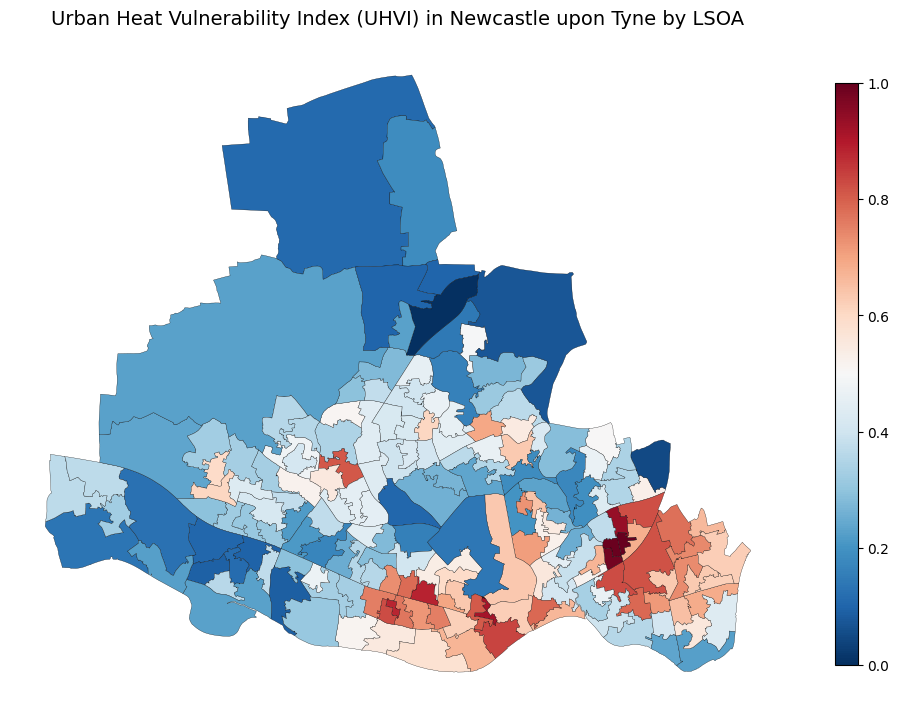

In [ ]:
# 4-7 Map Continuous UHVI (blue - low UHVI -> red - high UHVI)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="uhvi",
    cmap="RdBu_r",      # blue -> red
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,

    legend_kwds={
        "shrink": 0.6,
        "aspect": 25
    }
)

ax.set_title(
    "Urban Heat Vulnerability Index (UHVI) in Newcastle upon Tyne by LSOA",
    fontsize=14,
    pad=15
)

ax.axis("off")

plt.tight_layout()

# Save figure
output_path = f"{output_dir}/uhvi_map_continuous.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("Saved:", output_path)

plt.show()